In [1]:
import sys
import os

sys.path.insert(0, os.path.abspath("."))
sys.path.insert(0, os.path.abspath("."))
sys.path.append(os.path.abspath("../../"))

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from desc.plotting import *

In [65]:
def plot_iotas(name):
    data = np.loadtxt(name+".txt")
    r = data[0, :]
    base = data[1, :]
    indices = np.arange(len(base))[3:-1]
    currents = np.arange(1, 10)
    plt.plot(
        r[indices], np.abs(base)[indices], label="No Current", color="navy", linewidth=2
    )
    for i, di in enumerate(data[2:, :]):
        last_not_nan_idx = np.where(
            ~np.isnan(di[indices]), np.arange(len(indices)), 0
        ).max()
        percent = (
            100
            * (
                np.abs(di)[indices][last_not_nan_idx]
                - np.abs(base)[indices][last_not_nan_idx]
            )
            / np.abs(base)[indices][last_not_nan_idx]
        )
        plt.plot(
            r[indices],
            np.abs(di)[indices],
            label=f"{currents[i]} kA, ({percent:.2f}%)",
            color=plt.cm.Blues(0.8 - 0.6 * i / (len(data) - 2)),
        )

    plt.xlabel("R (m)")
    plt.ylabel("|Iota|")
    plt.title(
        "Ip=14kA, B0=0.35T, 1 Umbilic Coil"
        if "1coil" in name
        else "Ip=14kA, B0=0.35T, 2 Umbilic Coil"
    )
    plt.legend()
    plt.grid(True, alpha=0.3)

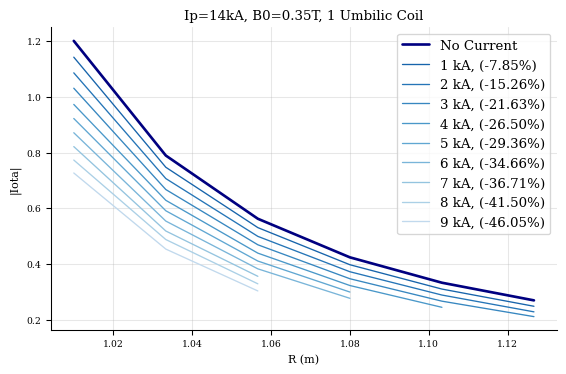

In [67]:
name = "1coil-R0-0.92-B0-0.35-rmaj-0.97-rmin-0.2-Ip-14000.0-Ic-n1-9kA"
plot_iotas("Scans/data-" + name)
plt.savefig(f"Scans/iotas-{name}.png", dpi=500)